## Instruction for Assignment 1 Submission

- This is an individual assessment. Refrain from working in groups. We will use plagiarism detectors after the submission. So, do not engage in unethical activities.
- Name your jupyter notebook before the submission as `Assignment1_[StudentID].ipynb`. For instance: `Assignment1_A0123873A.ipynb`.
- Your solution notebook must contain the python code that we can run to verify the answers.
- Please submit the final and clean version of the code.
- **Do not delete the output blocks in your submission.**
- Upload your jupyter notebook on Canvas in the *Assignment 1*. **The assignment will close at 6pm on 19/09/2025**. Late submissions will receive a penalty on the grade as follows:
  - late within 1 hour: 10% reduction in grade
  - late within 6 hours: 30% reduction in grade
  - late within 12 hours: 50% reduction in grade
  - late within 1 days: 70% reduction in grade
  - after 1 days: zero mark

## 0. Preparation

### Dataset Description

Link to dataset : [Default of Credit Card Clients](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients)

This dataset records this customers' default payments in Taiwan.

This research employed a binary variable, `default payment next month` (Yes = 1, No = 0), as the response variable. This study consists of the following explanatory variables :

* `LIMIT_BAL`: Amount of the given credit (NT dollar): it includes both the individual consumer credit and his/her family (supplementary) credit.
* `SEX`: Gender (1 = male; 2 = female).
* `EDUCATION`: Education (1 = graduate school; 2 = university; 3 = high school; 4 = others).
* `MARRIAGE`: Marital status (1 = married; 2 = single; 3 = others).
* `AGE`: Age (year).
* `PAY_0` - `PAY_6`: History of past payment.
  - We tracked the past monthly payment records (from April to September, 2005) as follows: `PAY_0` = the repayment status in September, 2005; `PAY_2` = the repayment status in August, 2005; . . .;`PAY_6` = the repayment status in April, 2005.
  - The measurement scale for the repayment status is: -1 = pay duly; 1 = payment delay for one month; 2 = payment delay for two months; . . .; 8 = payment delay for eight months; 9 = payment delay for nine months and above.
* `BILL_AMT1` - `BILL_AMT6`: Amount of bill statement (NT dollar).
  - `BILL_AMT1` = amount of bill statement in September, 2005; `BILL_AMT2` = amount of bill statement in August, 2005; . . .; `BILL_AMT6` = amount of bill statement in April, 2005.
* `PAY_AMT1`-`PAY_AMT6`: Amount of previous payment (NT dollar).
  - `PAY_AMT1` = amount paid in September, 2005; `PAY_AMT2` = amount paid in August, 2005; . . .;`PAY_AMT6` = amount paid in April, 2005.

### Mount Google Drive

Use this mounting code if you are running this notebook on Google Colab.

Use `%cd` to change the directory (folder) where you save this assignment notebook. Save the dataset in the same directory as this notebook.

Below example shows that this notebook is saved in the `a1` folder of the user's Google Drive, with the folder path of `TA/IT5006/assignments/a1` folder.

In [1]:
# from google.colab import drive
# drive.mount('/content/gdrive')

In [2]:
# !ls

### Load Libraries and Dataset

In [3]:
from ucimlrepo import fetch_ucirepo, list_available_datasets
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.utils.validation import column_or_1d
from matplotlib import pyplot
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import category_encoders as ce
import warnings
import statistics
warnings.filterwarnings('ignore')

In [4]:
#data = pd.read_csv("default_of_credit_card_clients.csv") # replace with your own path here
#list_available_datasets()
credit = fetch_ucirepo(id=350)

In [5]:
X = credit.data.features 
y = credit.data.targets
X.head()


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


In [6]:
y.head()

,Y
0,1
1,1
2,0
3,0
4,0


## Question 1 - Understanding the Dataset (6 marks)

### Q1A (1 mark)

How many rows and columns are there in the dataset ? Are there any missing values in the dataset ? If yes, report the number of missing values in each column

*Note : You need to answer both questions correctly to get the full mark, no half mark awarded for this question.*

In [7]:
print(len(X))

30000


In [8]:
X.isnull().sum()

X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
X11    0
X12    0
X13    0
X14    0
X15    0
X16    0
X17    0
X18    0
X19    0
X20    0
X21    0
X22    0
X23    0
dtype: int64

**Answer:** There are 23 columns of features, ID Column and one target variable column giving a total of 25 columns. There are 30000 rows. There are no missing values when we apply the isnull function.

### Q1B (1 mark)

This research employed a binary variable, `default payment next month` (Yes = 1, No = 0), as the target variable (also known as response variable).

Aside from the target variable, identify and list the categorical features in this dataset.



**Answer:** X2(Sex), X3(Education Level), X4(Marital Status), X6(1st Month Payment Status),
X7(2nd Month Payment Status), X8(3rd Month Payment Status), X9(4th Month Payment Status)
X10(5th Month Payment Status), X11(6th Month Payment Status)

### Q1C (2 marks)

* Report the **proportion** (not count!) of default and non-default for the target variable `default payment next month`. Is the dataset balanced ?

* If you conclude that the dataset is imbalanced, please briefly explain what can you do to deal with this so our predictive model is not biased to the majority class during training ? Should you balance the dataset after or before splitting the dataset into training and test dataset, and why ?
  - *Note : You don't have to provide your code to balance the dataset, simply explain your method in text will do.*


In [9]:
default_y = y.query('Y > 0')
print(len(default_y) / len(y))

0.2212


**Answer:** The proportion of default is 22.12% of the total target data entries. The proportion of non-default is 77.88% of the total target data entries. The dataset is imbalanced. We can correct this by oversampling, generating artifical data for the minority default case. A novel technique for oversampling is called SMOTE. Unlike simply duplicating records, SMOTE enhances diversity by creating artificial instances using K-nearest neighbours. Balancing the dataset should be done after splitting the data into training and test datasets. Our test data should be independent of our training data to accurately measure the performance of the model. Having artificially generated samples in the test data will bias the test data.

### Q1D (1 mark)

Refer to the PDF resource : *The State of Low-Income America : Credit Access & Debt Payment (March 2022)* in the same folder as this assignment in Canvas or via this [link](https://www.newyorkfed.org/medialibrary/media/press/the-state-of-low-income-america-credit-access-debt-payment-march-2022) to answer this question.

The report shows that different income groups have varying credit behaviors and delinquency rates. Based on our dataset's available features, propose a comprehensive **risk profiling approach** that combines multiple features to categorize customers into different risk levels (e.g., Low, Medium, High risk).

Your approach should consider at least 3 different feature categories (e.g., payment behavior, credit utilization, demographics) and explain how each contributes to overall risk assessment.

*Note : You only need to detail your approach conceptually - no coding needed, but your explanation should be detailed and well-reasoned.*


**Answer:** The three features I would choose for risk profile are education level, total loan as a proportion of limit balance and age. A person with a high education level would have more expertise to earn a higher income and a lower chance of default. People who are either too young or too old might not be currently employed and hence have a higher chance of default. A person who borrows close to their loan limit will have a higher chance of default since they are less able to live within their means.

### Q1E (1 mark)

Refer to the PDF resource : *The State of Low-Income America : Credit Access & Debt Payment (March 2022)* in the same folder as this assignment in Canvas or via this [link](https://www.newyorkfed.org/medialibrary/media/press/the-state-of-low-income-america-credit-access-debt-payment-march-2022) to answer this question.


The report states :

> Credit card debt is the most commonly held debt across all income groups, yet only half of low-income households have access to a credit card.

> During the pandemic, all borrowers saw improvements in their payment rates. Low- and moderate-income debt holders consistently have the highest delinquency rates across credit products (card, auto, mortgage).

How could improved access to credit affect the financial stability of low- and moderate-income groups ? Would it reduce delinquency rates or increase financial risk for the bank ?









**Answer:** The report states that  auto and student loan debt is more constant across income groups compared to other credit products. This suggest low- and moderate-income groups already have access to credit to finance these items. Note also that low-income borrowers have the highest median loan balances, 29.1% higher than those of high-income borrowers. Access to credit is hence not the problem but the capacity to generate income to repay the loan. Extending credit to low and moderate income loans without some form of debt relief will increase delinquency rates and financial risk.

## Question 2 - Data Preprocessing (8 marks)

### Q2A (2 marks)

We clean the data with the following methods :

* Drop the `ID` column
* Rename the columns to lowercase and replace spaces with underscores '_'

In [10]:
#X = X.drop(columns=['ID']) Drop ID Column. ID already not in feature set
X.columns = X.columns.str.lower() #change to lowercase
X.columns = X.columns.str.replace(' ', '_') #replace spaces with underscore
X.head()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


### Q2B (2 marks)

There are some undocumented categories in the categorical variables of this dataset. If they are not processed, it could lead to inaccurate analysis and difficulty in interpreting the results of analysis.

Undocumented categories are values or labels within a categorical feature that are not explicitly defined or explained in the dataset's documentation or description.

* Aside from the 'others' and 'unknown' labels, which categorical variable has undocumented label(s) ? List the undocumented label(s) down for each categorical variable.
* For each categorical variable, group the undocumented label(s) with exisiting 'other' and 'unknown' labels. Use the numerical label for 'others' to represent this category


In [11]:
X['x6'].value_counts()

x6
 0    14737
-1     5686
 1     3688
-2     2759
 2     2667
 3      322
 4       76
 5       26
 8       19
 6       11
 7        9
Name: count, dtype: int64

In [12]:
X['x3'].value_counts()

x3
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

In [13]:
X['x4'].value_counts()

x4
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

The documented repayment status (-1=pay duly, 1=payment delay for one month, 2=payment delay for two months, … 8=payment delay for eight months, 9=payment delay for nine months and above). The undocumented labels for categorical variables x6[PAY_0], x7[PAY_2], x8[PAY_3], x9[PAY_4], x10[PAY_5], x11[PAY_6] is 0 and -2. For categorical variables x3(Education) and x4(Marital Status), the undocumented labels is 0.

In [14]:
#convert undocumented values to 4 (others) in education
X['x3'] = X['x3'].apply(lambda x: 4 if x == 5 else x)
X['x3'] = X['x3'].apply(lambda x: 4 if x == 6 else x)
X['x3'] = X['x3'].apply(lambda x: 4 if x == 0 else x)
X['x3'].value_counts()


x3
2    14030
1    10585
3     4917
4      468
Name: count, dtype: int64

In [15]:
#convert undocumented values and other to 4 (others) in marriage
#X.loc[X['x4'] == 0] = 4
#X.loc[X['x4'] == 3] = 4

X['x4'] = X['x4'].apply(lambda x: 4 if x == 0 else x)
X['x4'] = X['x4'].apply(lambda x: 4 if x == 3 else x)

X['x4'].value_counts()


x4
2    15964
1    13659
4      377
Name: count, dtype: int64

### Q2C (4 marks)

Next, we will proceed create some new features to further investigate the customer behaviours :

* Compute the **payment consistency score** - calculate the standard deviation of payment status across all PAY_X columns (PAY_0 to PAY_6), then create a binary feature where 1 indicates consistent payment behavior (low standard deviation) and 0 indicates inconsistent payment behavior. Name this new column `payment_consistency`.

* Compute the **average utilization ratio** - calculate the mean of monthly bill amounts divided by credit limit across all 6 months (BILL_AMT1 to BILL_AMT6 divided by LIMIT_BAL). Name this new column `avg_utilization_ratio`.

* How is `payment_consistency` helpful in predicting whether the customer will default or not ? Explain your answer.

* How is `avg_utilization_ratio` helpful in predicting whether the customer will default or not ? Explain your answer.


In [16]:
#conver -1 to 0, more accurate as 0 days means 0 days late

X['x6'] = X['x6'].apply(lambda x: 0 if x == -1 else x)
X['x7'] = X['x7'].apply(lambda x: 0 if x == -1 else x)
X['x8'] = X['x8'].apply(lambda x: 0 if x == -1 else x)
X['x9'] = X['x9'].apply(lambda x: 0 if x == -1 else x)
X['x10'] = X['x10'].apply(lambda x: 0 if x == -1 else x)
X['x11'] = X['x11'].apply(lambda x: 0 if x == -1 else x)

combined_array = list(X['x6']) + list(X['x7']) + list(X['x8']) + list(X['x9']) + list(X['x10']) + list(X['x11'])
combined_dev = statistics.stdev(combined_array)
print(len(combined_array))
print(combined_dev)
payment_consistency = X[['x6','x7','x8','x9', 'x10','x11']].std(axis=1, numeric_only=True)
payment_consistency = payment_consistency.apply(lambda x: 1 if x <= combined_dev else 0)
#pd.concat([X, payment_consistency])
#X.loc[X['payment_consistency'] <= 0.5] = 1
#X.loc[X['payment_consistency'] != 1] = 0
payment_consistency.value_counts()

180000
1.0951970382107223


1    26552
0     3448
Name: count, dtype: int64

In [17]:
avg_utilization_ratio = X[['x12','x13','x14','x15', 'x16','x17']].mean(axis=1)
avg_utilization_ratio = avg_utilization_ratio / X['x1']
#X['avg_utilization_ratio'] = X[['x12','x13','x14','x15', 'x16','x17']].mean(axis=1)
#pd.concat([X,average])
#print(average)
#X['avg_utilization_ratio'] = X['avg_utilization_ratio'] / X['x1']
print(avg_utilization_ratio)

0        0.064200
1        0.023718
2        0.188246
3        0.771113
4        0.364463
           ...   
29995    0.549507
29996    0.023536
29997    0.391644
29998    0.555440
29999    0.769580
Length: 30000, dtype: float64


**Explanation of Features:**

**Payment Consistency:** The client that has a positive payment consistency (low standard deviation) has a lower probability of default. This is because they demonstrate the capability to pay their bills witin a small duration from the stipulated payment date.


**Average Utilization Ratio:** The client that has a low average utilization ratio has a lower probability of default. This is because they do max out their assigned credit limit and hence have more financial buffer to pay on time.


## Question 3 - Data Visualization (6 marks)

### Q3A (2 marks)

Visualize the relationship between education level (`education`) and default status (`default_payment_next_month`) using a grouped bar chart

Follow these specific requirements :
* Label the x-axis as "Education Level"
* Label the y-axis as "Count"
* Include a 'Default Status' legend that clearly distinguishes the two classes of default status. Use 'Non Default' for class 0 and 'Default' for class 1
* Include a title to the plot : "Education Level by Default Status"
* (Optional) Include bar labels that represent the number of counts



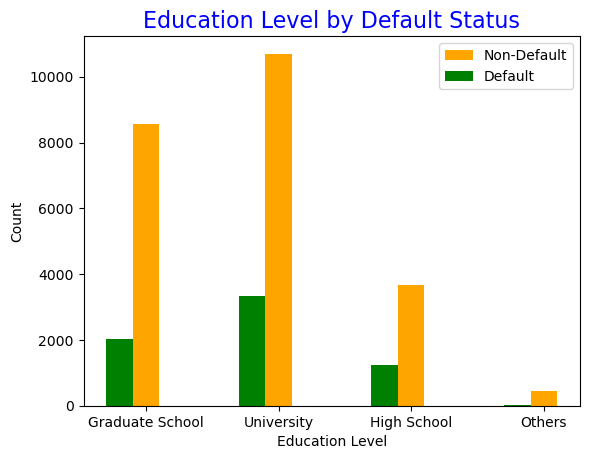

In [18]:
Z = pd.concat([X,y],axis = 1)
x = np.arange(4)
width =0.2
graduateDefault = len(Z.query('x3 == 1 and Y == 1'))
graduateNonDefault = len(Z.query('x3 == 1 and Y == 0'))
uniDefault = len(Z.query('x3 == 2 and Y == 1'))
uniNonDefault = len(Z.query('x3 == 2 and Y == 0'))
highSchoolDefault = len(Z.query('x3 == 3 and Y == 1'))
highSchoolNonDefault = len(Z.query('x3 == 3 and Y == 0'))
othersDefault = len(Z.query('x3 == 4 and Y == 1'))
othersNonDefault = len(Z.query('x3 == 4 and Y == 0'))

y0 = [graduateNonDefault, uniNonDefault, highSchoolNonDefault, othersNonDefault]
y1 = [graduateDefault, uniDefault, highSchoolDefault, othersDefault]


pyplot.bar(x, y0, width, color='orange')
pyplot.bar(x-0.2, y1, width, color='green')
pyplot.xticks(x, ['Graduate School', 'University', 'High School', 'Others'])
pyplot.xlabel("Education Level")
pyplot.ylabel("Count")
pyplot.legend(["Non-Default", "Default"])
pyplot.title("Education Level by Default Status", fontsize=16, color='blue', loc='center')
pyplot.show()

### Q3B (1 mark)

Except for the 'others' category, which education level has the highest default *rate*, in relative to its total count ?  Report the default rate of this category and explain your reasonings regarding its relationship with defaulting.

In [19]:
print(uniDefault/(uniDefault + uniNonDefault))
print(graduateDefault /(graduateDefault + graduateNonDefault))
print(highSchoolDefault /(highSchoolDefault + highSchoolNonDefault))

0.23734853884533144
0.19234766178554558
0.2515761643278422



**Answer:** The highest default rate are those with a high school education. Having less education opportunities reduces the earning potential of the individual.

### Q3C (2 marks)

Create a correlation heatmap showing the relationships between the following variables: `age`, `limit_bal`, `avg_utilization_ratio` (from Q2C), and `default_payment_next_month`.

Follow these specific requirements :
* Use a diverging color palette (e.g., 'RdBu_r' or 'coolwarm')
* Display correlation coefficients on the heatmap with 2 decimal places
* Label the plot with title: "Correlation Matrix of Key Financial Variables"
* Set the figure size to (8, 6)


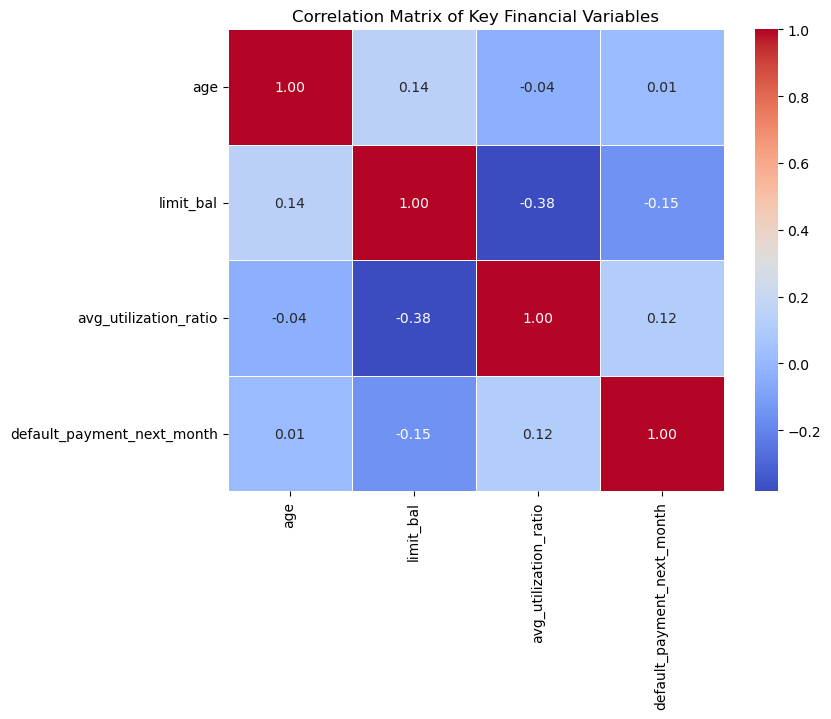

In [20]:
labels = ['age', 'limit_bal', 'avg_utilization_ratio', 'default_payment_next_month']
res = pd.concat([X['x5'], X['x1'], avg_utilization_ratio, y], axis=1)

correlation_matrix = res.corr()

# Create the heatmap
pyplot.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, 
            xticklabels= labels, yticklabels=labels)

# Add title
pyplot.title('Correlation Matrix of Key Financial Variables')

# Show the plot
pyplot.show()

### Q3D (1 mark)

Based on the correlation heatmap from Q3C, identify the variable that has the max positive correlation with the default status (`default_payment_next_month`). Discuss why this relationship might exist from a financial risk perspective.

**Answer:** The max positive correlation with the default status is the average utilization ratio. People who maximize their loan to the default limit have a higher risk of default since they take on more debt in proportion to their income.